In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import preprocess_maps

# returns N_H2, N_H2_OA, N_H2_OB, wcs, wcs_OA, wcs_OB (preprocessed maps)
N_H2, N_H2_OA, N_H2_OB, wcs, wcs_OA, wcs_OB = preprocess_maps.derive_density_maps()

# returns M_H2_OA, M_H2_OB (mass maps)
M_H2_OA = preprocess_maps.convert_to_mass(N_H2_OA)
M_H2_OB = preprocess_maps.convert_to_mass(N_H2_OB)

Using: /home/simone/Documents/Astronomy/Paper Fractal ISM/01_code/Fractal_Star_Formation/inputs/Lombardi_maps/planck_herschel.fits.gz


/home/simone/Documents/Astronomy/Paper Fractal ISM/01_code/Fractal_Star_Formation/src/plot_tools.py:93: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label("Column Density Threshold [$\mathrm{cm}^{-2}$]", fontsize=15)
/home/simone/Documents/Astronomy/Paper Fractal ISM/01_code/Fractal_Star_Formation/src/plot_tools.py:132: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Column Density Threshold [$\mathrm{cm}^{-2}$]', fontsize=13)


Correlation coefficient: 0.9883
Slope: 1.4689 ± 0.0229
Fractal dimension D = 1.36 ± 0.02
Average residual (very symmentrical): -0.0000
Mean absolute residual: 0.1180


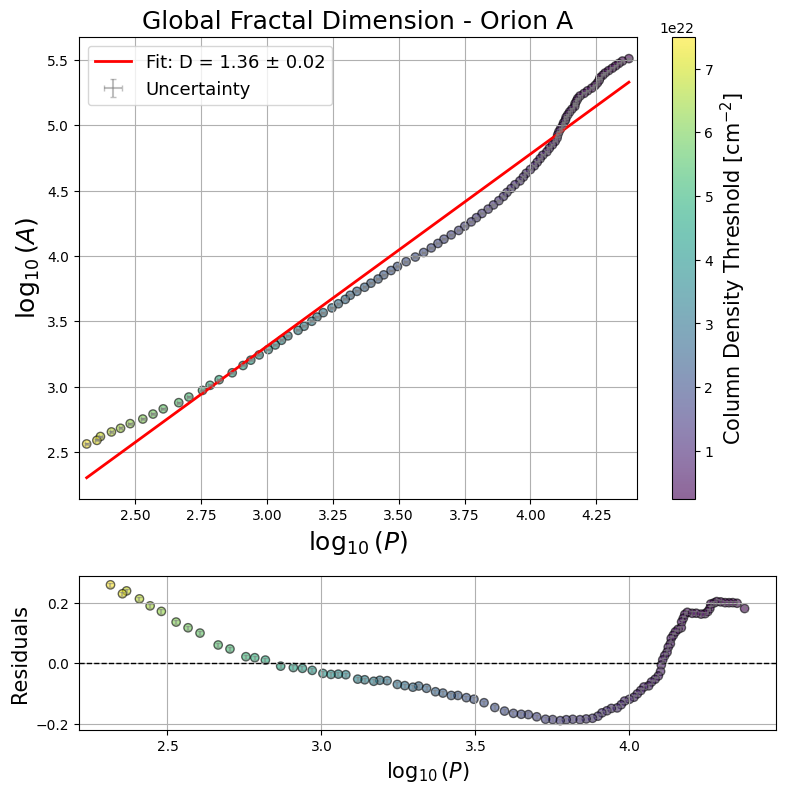

In [2]:
from src import minkowski_functionals, plot_tools
import numpy as np

# Orion A
name_region = "Orion A"

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down
# threshold_max = 1.0e23

# Minkowski
results_OA = minkowski_functionals.compute_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)
plot_tools.plot_global_fractal_dimension(results=results_OA, threshold_min=threshold_min, threshold_max=threshold_max, name_region=name_region)

fractal_dimension_OA = results_OA["fractal_dimension"]

#TODO: double fit, errors etc.. (Global Properties)

Correlation coefficient: 0.9976
Slope: 1.4301 ± 0.0101
Fractal dimension D = 1.40 ± 0.01
Average residual (very symmentrical): -0.0000
Mean absolute residual: 0.0494


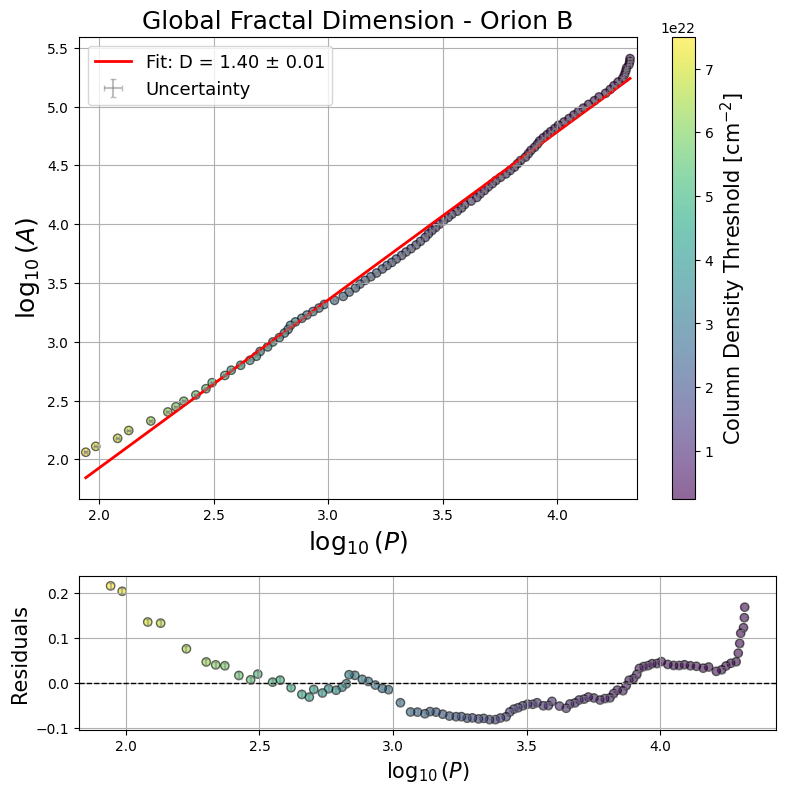

In [3]:
# Orion B
name_region = "Orion B"

# Minkowski
results_OB = minkowski_functionals.compute_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)
plot_tools.plot_global_fractal_dimension(results=results_OB, threshold_min=threshold_min, threshold_max=threshold_max, name_region=name_region)

fractal_dimension_OB = results_OB["fractal_dimension"]

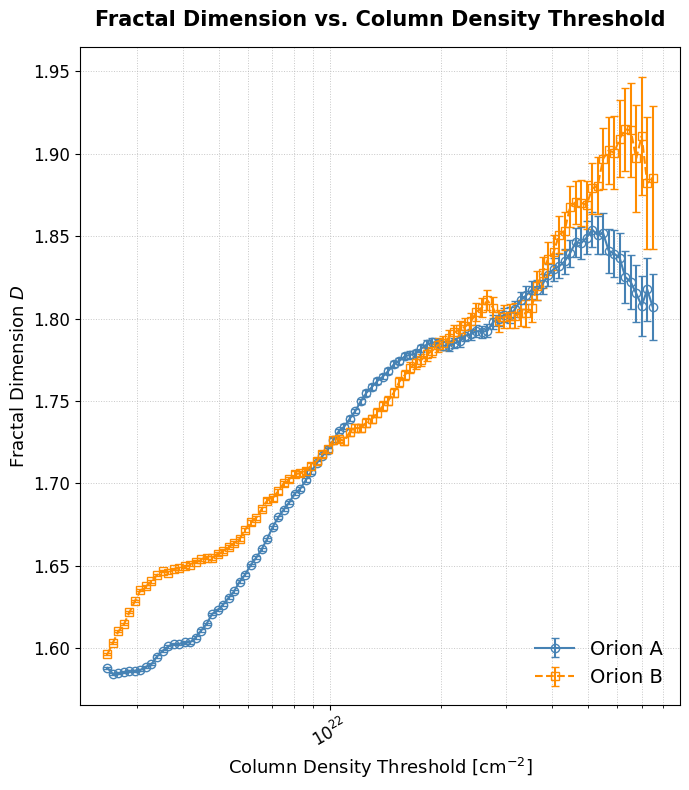

In [4]:
import matplotlib.pyplot as plt

plot_tools.plot_global_fractal_dimension_together(results_OA=results_OA, results_OB=results_OB)